# Undersampling methods on the hard / imbalanced datasets

Notebooks 05 and 06 showed the resampling-based *special ensembles* don't beat
the standard ensembles on these datasets. This notebook asks the related
question for the *undersampling methods*: if we undersample the training data
and then fit an ordinary ensemble, does any undersampler help?

Methodology matches notebook 03: undersampling is applied once per dataset (3
stratified folds, original test folds), models are tuned with the manual
successive-halving routine (100 candidates), and everything is evaluated at the
optimal threshold.

**Scope.** The full 10-method suite (RandomUnderSampler plus the neighbour-based
CNN, Tomek, OSS, ENN, RENN, AllKNN, NCR, NearMiss-1/2) is run on the three
datasets where it finishes in reasonable time (htru2, default_credit, secom).
The neighbour-based methods are very slow on large data (days-scale), so the
two largest datasets (diabetes130 ~71k, creditcard ~199k) get the row-reducing
methods only (RandomUnderSampler, NearMiss).

It also tests two ideas about the cleaning methods on low-separability data:
(1) do they remove *more* than on well-separated data, and (2) does removing the
borderline / hard-to-classify examples improve performance at the optimal
threshold?

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.analysis import create_df
from functions.plotting import compute_ylim

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

## Load results

Merge the plain-ensemble baselines (no resampling) with the undersampling results.

In [3]:
scores_dict = {}
for path in ['../models/ensembles-hard/results', '../models/ensembles-imbalanced/results']:
    with open(path, 'rb') as f:
        for ds, d in pickle.load(f).items():
            scores_dict.setdefault(ds, {}).update(d)
with open('../models/undersampling-new/results', 'rb') as f:
    for ds, d in pickle.load(f).items():
        scores_dict.setdefault(ds, {}).update(d)

datasets = ['htru2', 'default_credit', 'secom', 'diabetes130', 'creditcard']
plain_models = ['rf', 'ada', 'gbm', 'cat', 'lgbm', 'xgb']
{ds: len(scores_dict[ds]) for ds in datasets}

{'htru2': 66,
 'default_credit': 66,
 'secom': 66,
 'diabetes130': 24,
 'creditcard': 24}

## Removal rate vs class separability

Best standard-ensemble ROC-AUC is a proxy for how separable the classes are
(higher = easier). The hypothesis: the cleaning methods (edited-NN family)
remove *more* of the majority on the harder, less-separable datasets, because
more examples sit in the overlapping/borderline region.

In [4]:
with open('../models/undersampling-new/sampling_stats', 'rb') as f:
    sampling_stats = pickle.load(f)
rows = []
for ds, per in sampling_stats.items():
    for samp, st in per.items():
        rows.append({'dataset': ds, 'undersampler': samp,
                     'removed_pct': st['removed_pct']})
removal = pd.DataFrame(rows).pivot(index='undersampler', columns='dataset', values='removed_pct')
# order datasets by separability (best plain-ensemble ROC), easiest first
sep = {ds: max(scores_dict[ds][m][0] for m in plain_models) for ds in removal.columns}
removal = removal[sorted(removal.columns, key=lambda d: -sep[d])]
print('best plain-ensemble ROC-AUC (separability proxy):')
print({d: round(sep[d], 3) for d in removal.columns})
removal

best plain-ensemble ROC-AUC (separability proxy):
{'creditcard': np.float64(0.983), 'htru2': np.float64(0.979), 'secom': np.float64(0.792), 'default_credit': np.float64(0.784), 'diabetes130': np.float64(0.678)}


dataset,creditcard,htru2,secom,default_credit,diabetes130
undersampler,,,,,
allknn,NaN,6.6,29.1,53.3,NaN
cnn,NaN,83.1,71.2,52.0,NaN
enn,NaN,3.7,15.0,30.5,NaN
ncr,NaN,3.9,13.4,27.1,NaN
nm1,95.3,80.9,85.8,55.3,77.7
nm2,95.3,80.9,85.8,55.3,77.7
oss,NaN,7.8,2.0,6.3,NaN
renn,NaN,4.6,17.6,44.2,NaN
rus,95.3,80.9,85.8,55.3,77.7


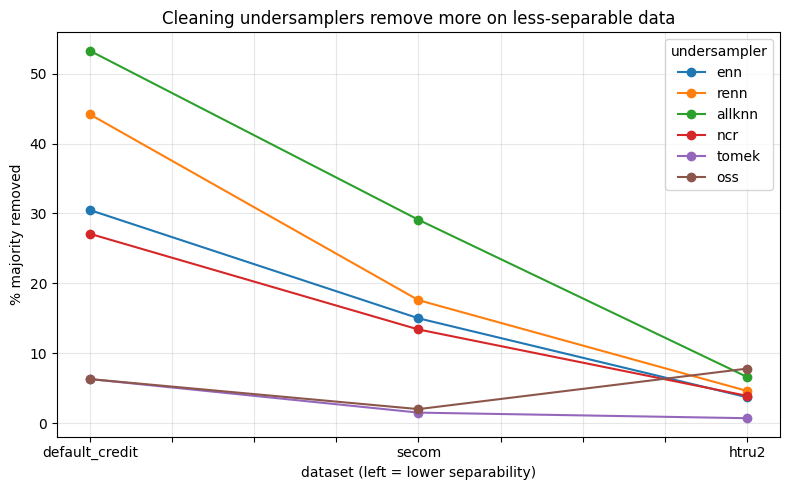

In [5]:
# edited-NN cleaning methods: removal vs separability
cleaning = [m for m in ['enn', 'renn', 'allknn', 'ncr', 'tomek', 'oss'] if m in removal.index]
order = sorted(removal.columns, key=lambda d: sep[d])  # hardest -> easiest
ax = removal.loc[cleaning, order].T.plot(marker='o', figsize=(8, 5))
ax.set_xlabel('dataset (left = lower separability)')
ax.set_ylabel('% majority removed')
ax.set_title('Cleaning undersamplers remove more on less-separable data')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/undersampling-new_removal-vs-separability.png', dpi=150, bbox_inches='tight')
plt.show()

## Performance per metric

Per dataset: plain ensembles plus every undersampled ensemble. The pink band is
the random forest (no resampling) reference. A method 'helps' only if it sits
clearly above the band. All threshold-based metrics are at their optimal
threshold.

In [6]:
def plot_metric(metric, std_metric, title, fname):
    fig, axes = plt.subplots(len(datasets), 1, figsize=(16, 4 * len(datasets)))
    for ax, data in zip(axes, datasets):
        models = list(scores_dict[data].keys())
        df = create_df(scores_dict, data, models)
        means, stds = df[metric], df[std_metric]
        upper = df.loc['rf', metric] + df.loc['rf', std_metric]
        lower = df.loc['rf', metric] - df.loc['rf', std_metric]
        colors = ['tab:blue' if m in plain_models else 'tab:green' for m in df.index]
        ax.errorbar(x=df.index, y=means, yerr=stds, fmt='none', ecolor='gray', capsize=3, zorder=1)
        ax.scatter(df.index, means, c=colors, s=45, zorder=2)
        ax.set_title(data, fontsize=13)
        ax.set_ylim(compute_ylim(means, stds, upper, lower))
        ax.tick_params(axis='x', rotation=90, labelsize=7)
        ax.grid(True, alpha=0.3)
        ax.axhline(upper, color='r', ls='--', alpha=0.5)
        ax.axhline(lower, color='r', ls='--', alpha=0.5)
        ax.axhspan(lower, upper, facecolor='pink', alpha=0.3)
    plt.suptitle(title, fontsize=15, y=1.005)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# blue = plain ensembles, green = undersampled ensembles; pink band = RF +/- std

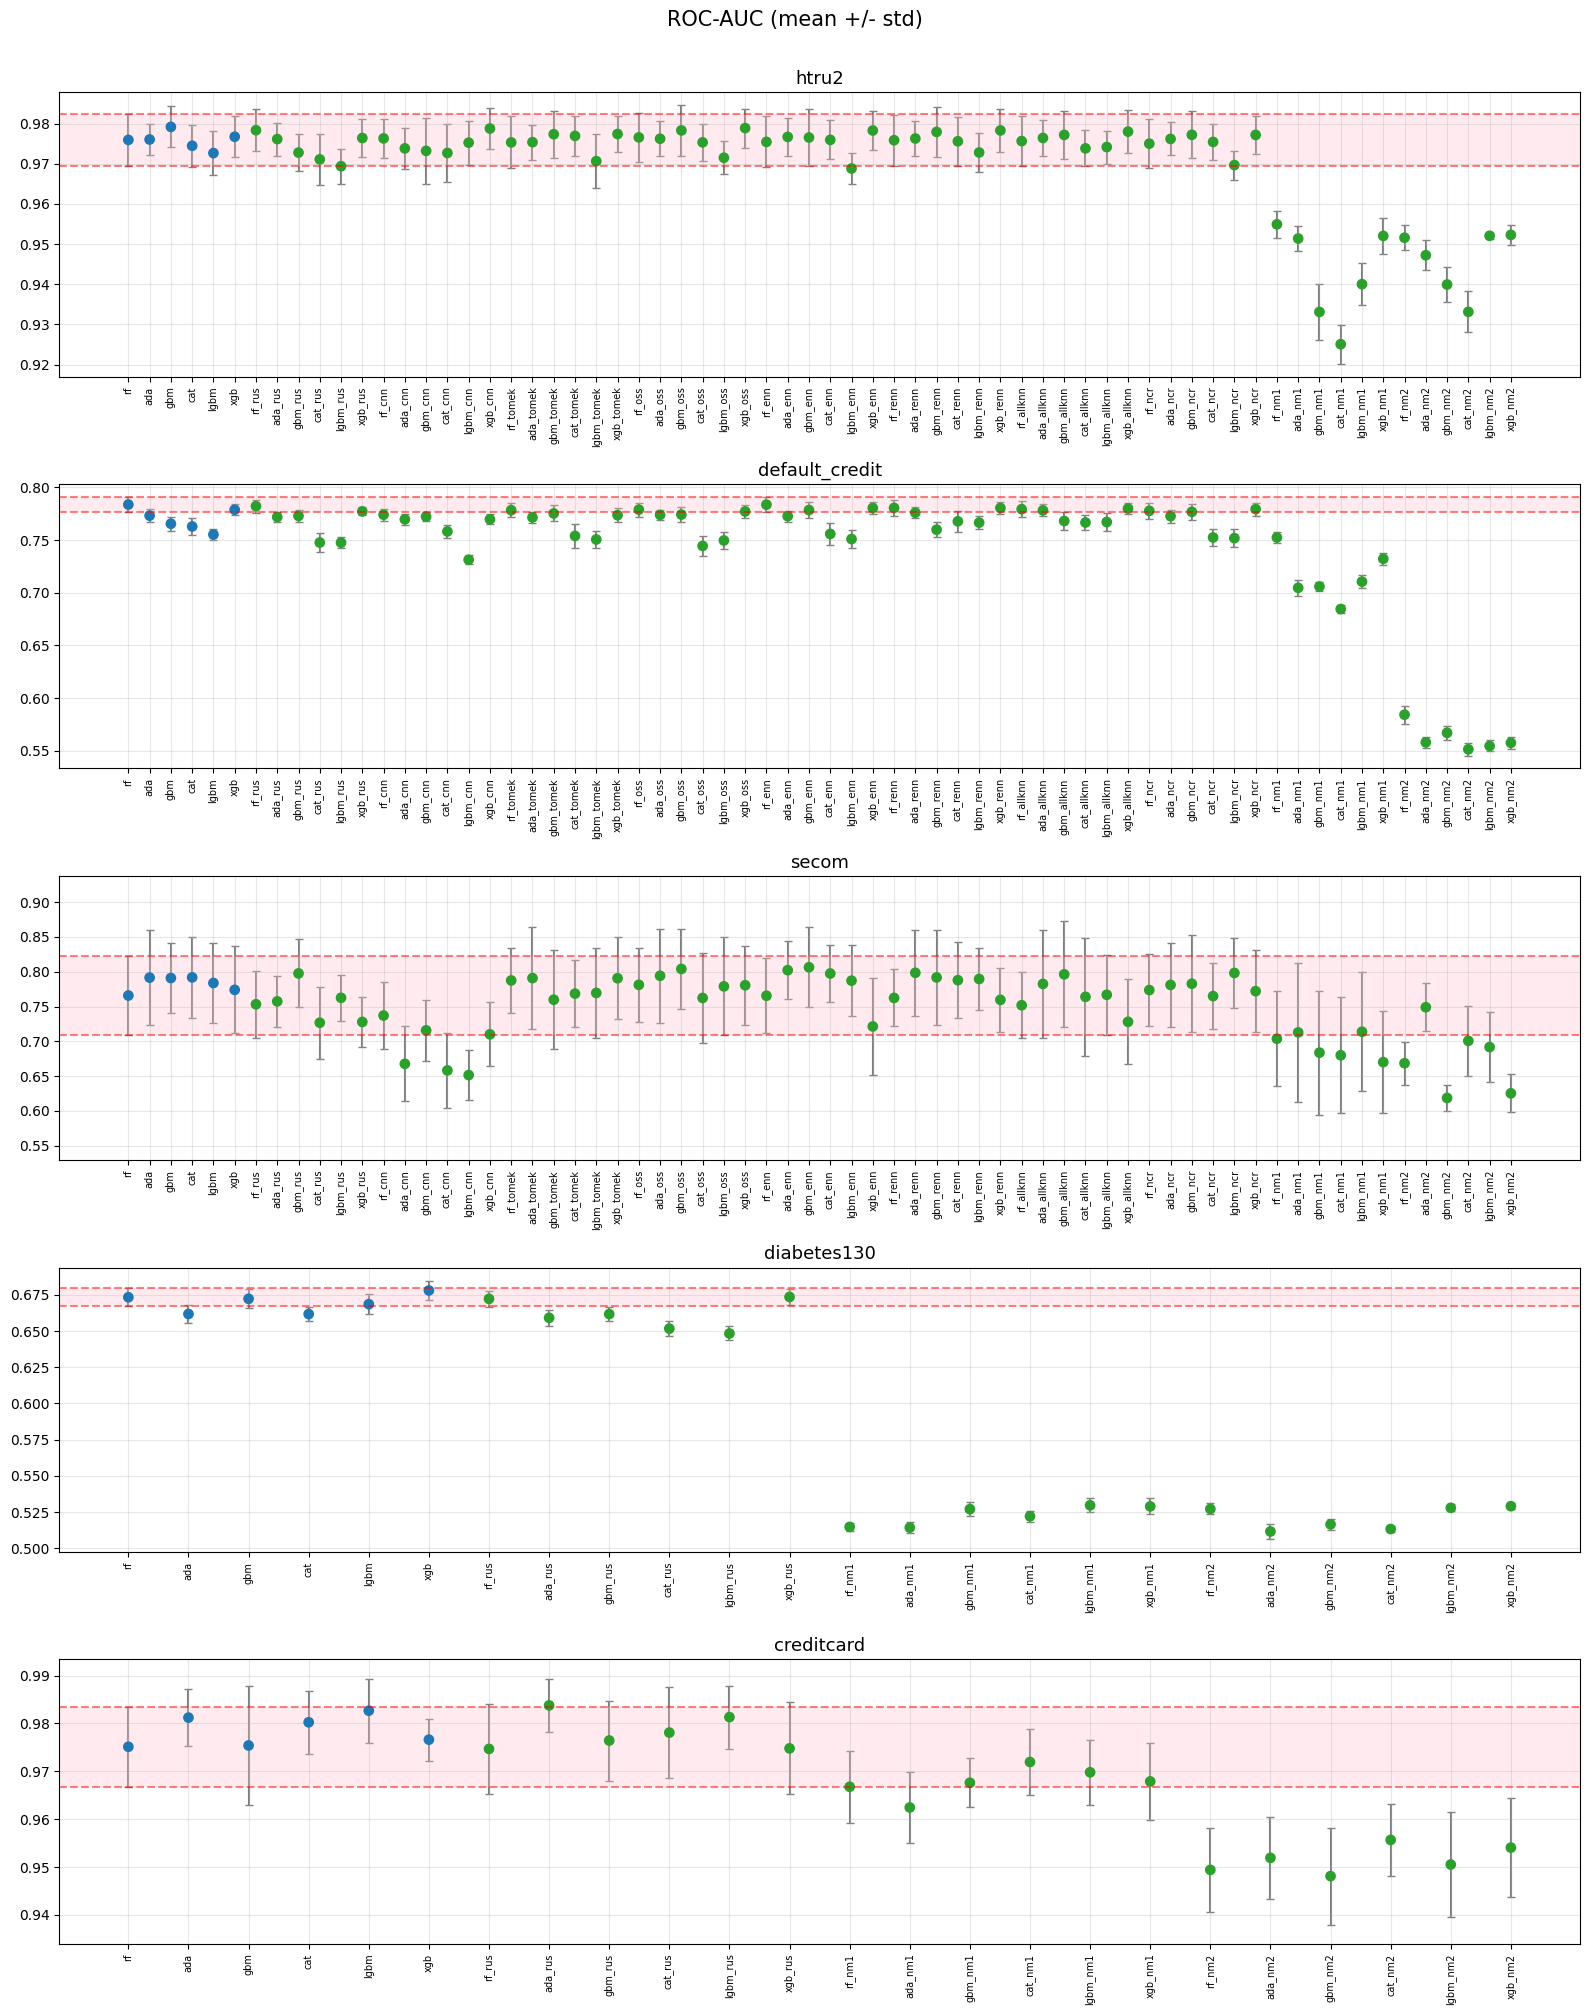

In [7]:
plot_metric('roc', 'roc_std', 'ROC-AUC (mean +/- std)', '../figures/undersampling-new_rocauc.png')

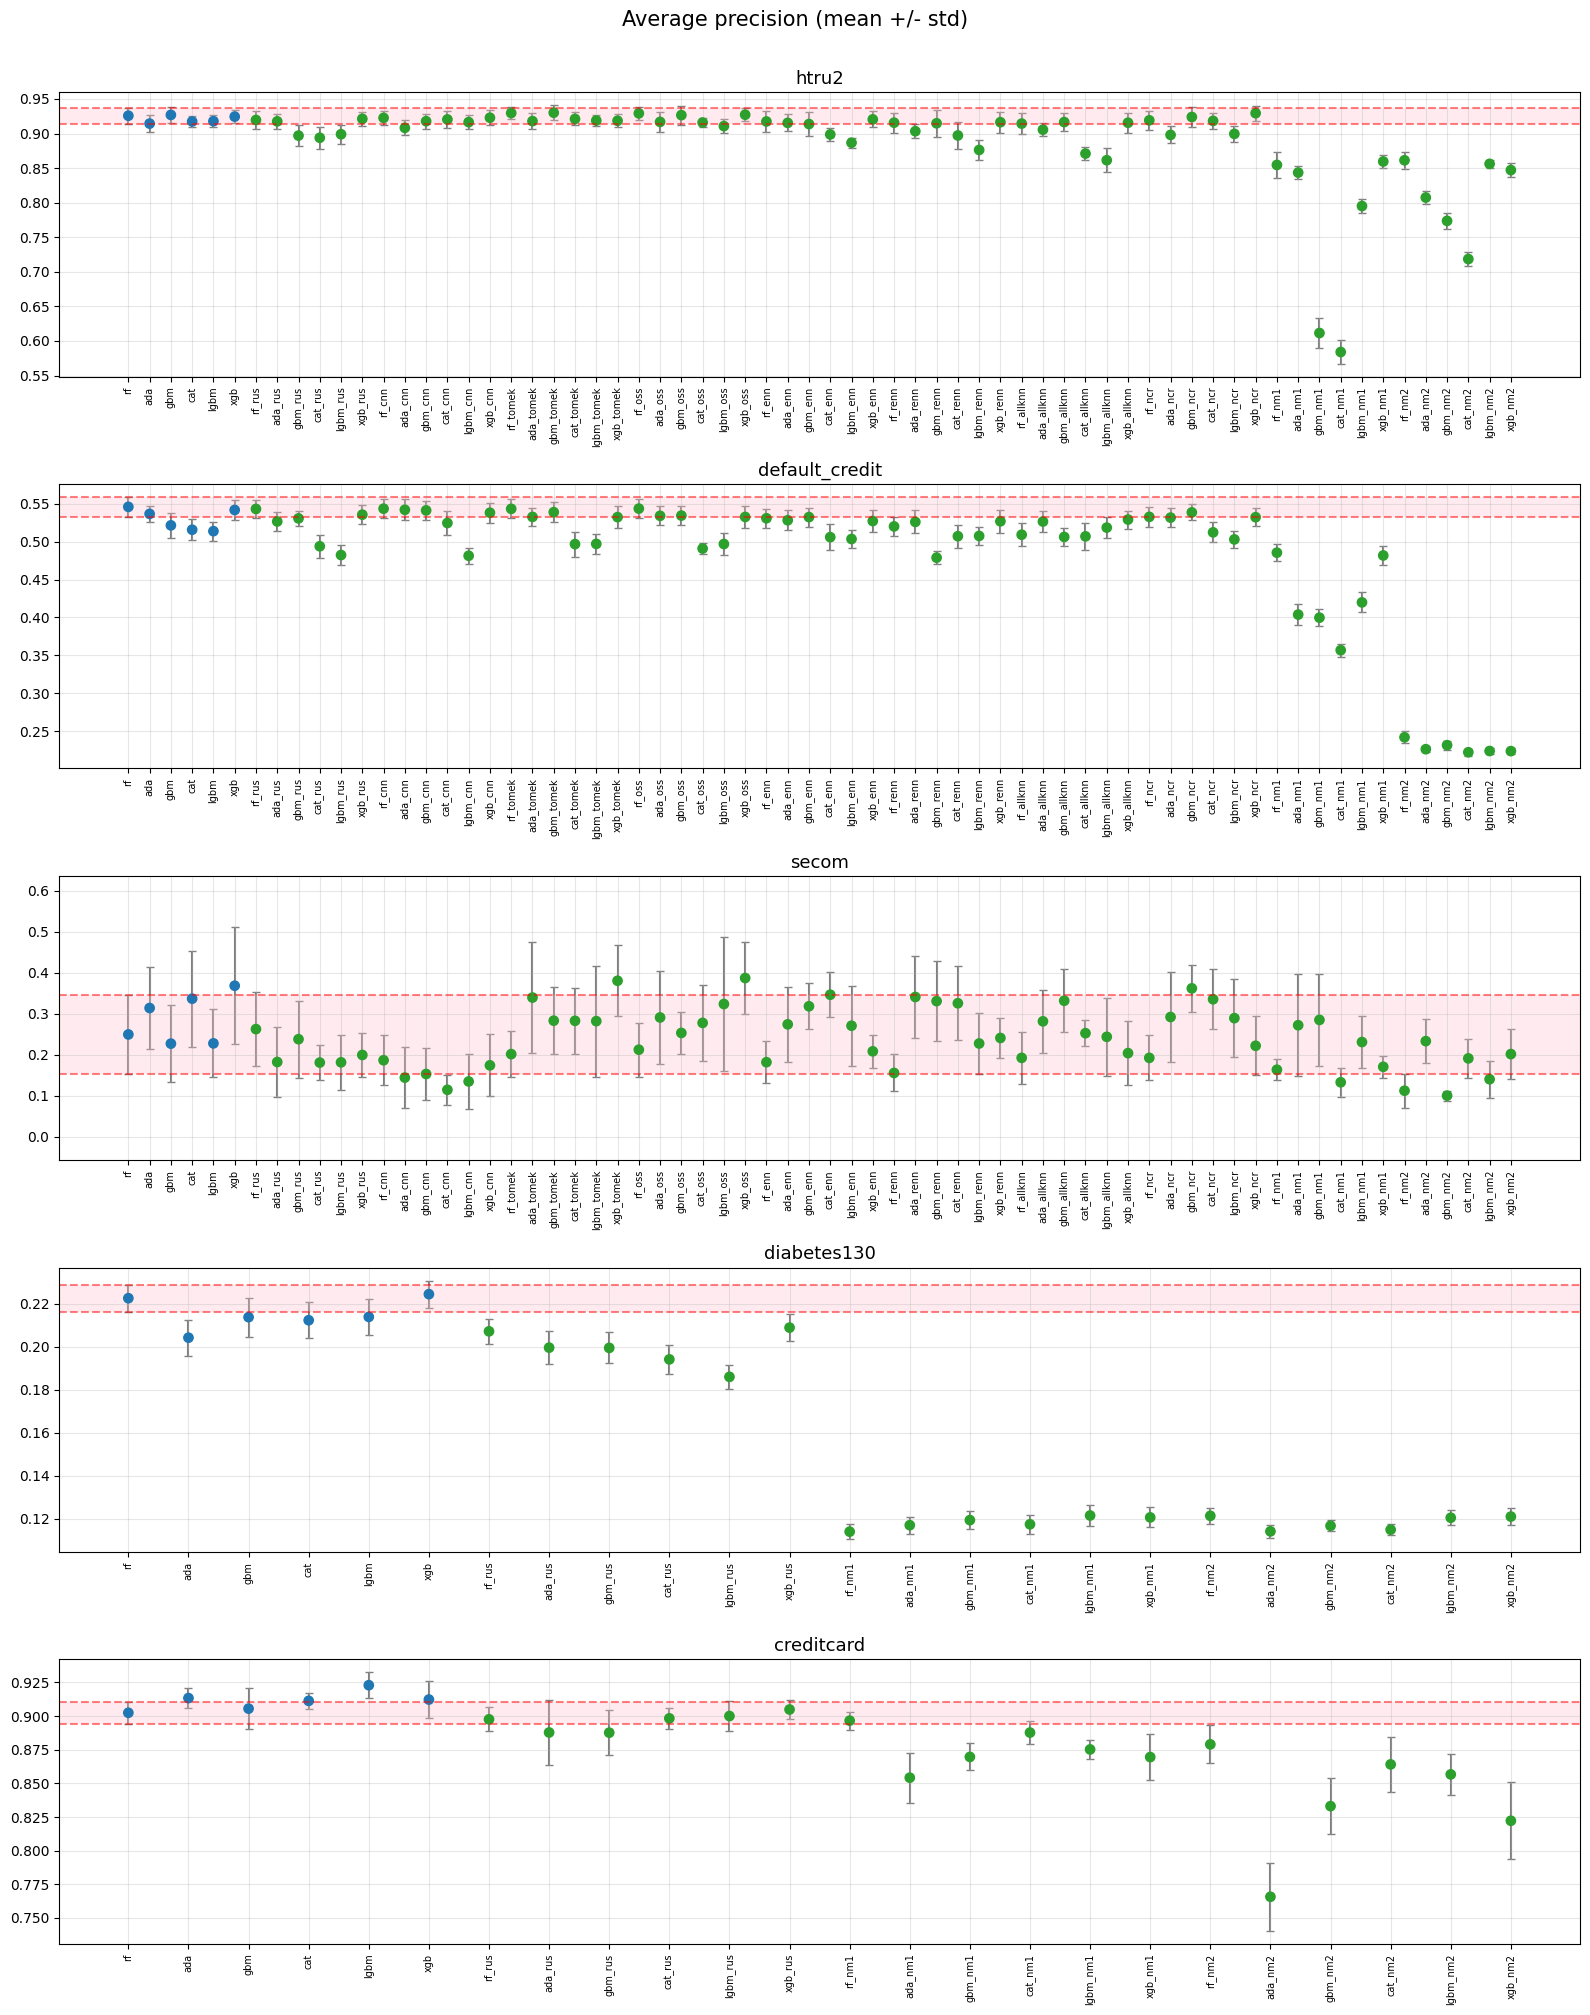

In [8]:
plot_metric('ap', 'ap_std', 'Average precision (mean +/- std)', '../figures/undersampling-new_ap.png')

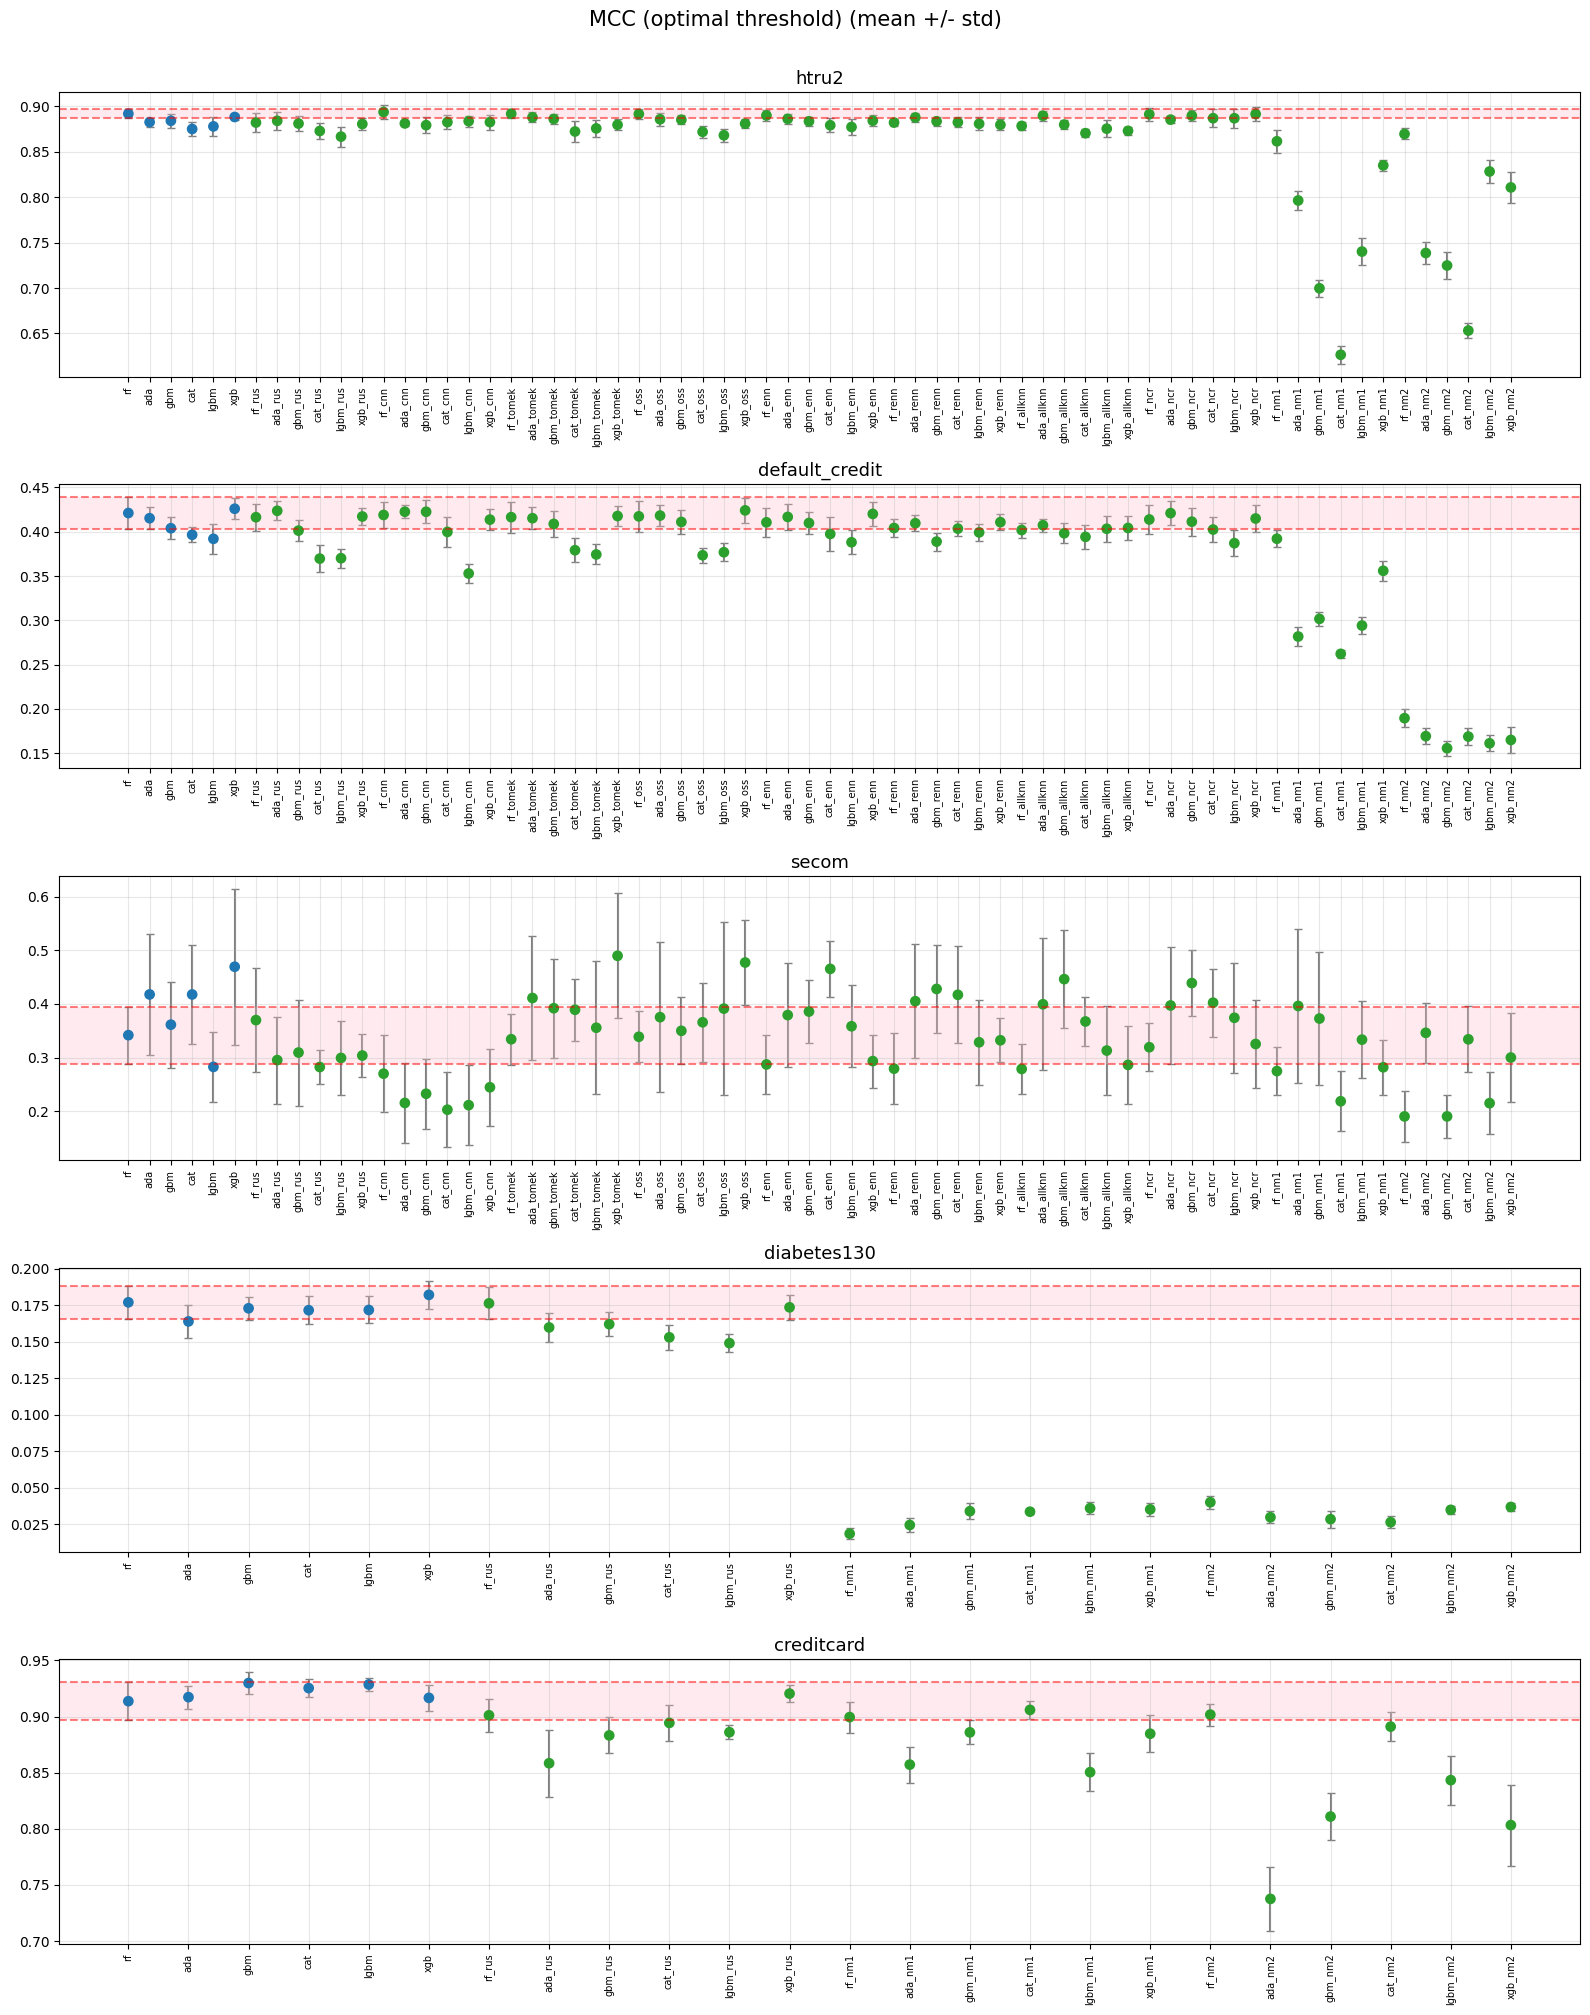

In [9]:
plot_metric('mcc', 'mcc_std', 'MCC (optimal threshold) (mean +/- std)', '../figures/undersampling-new_mcc.png')

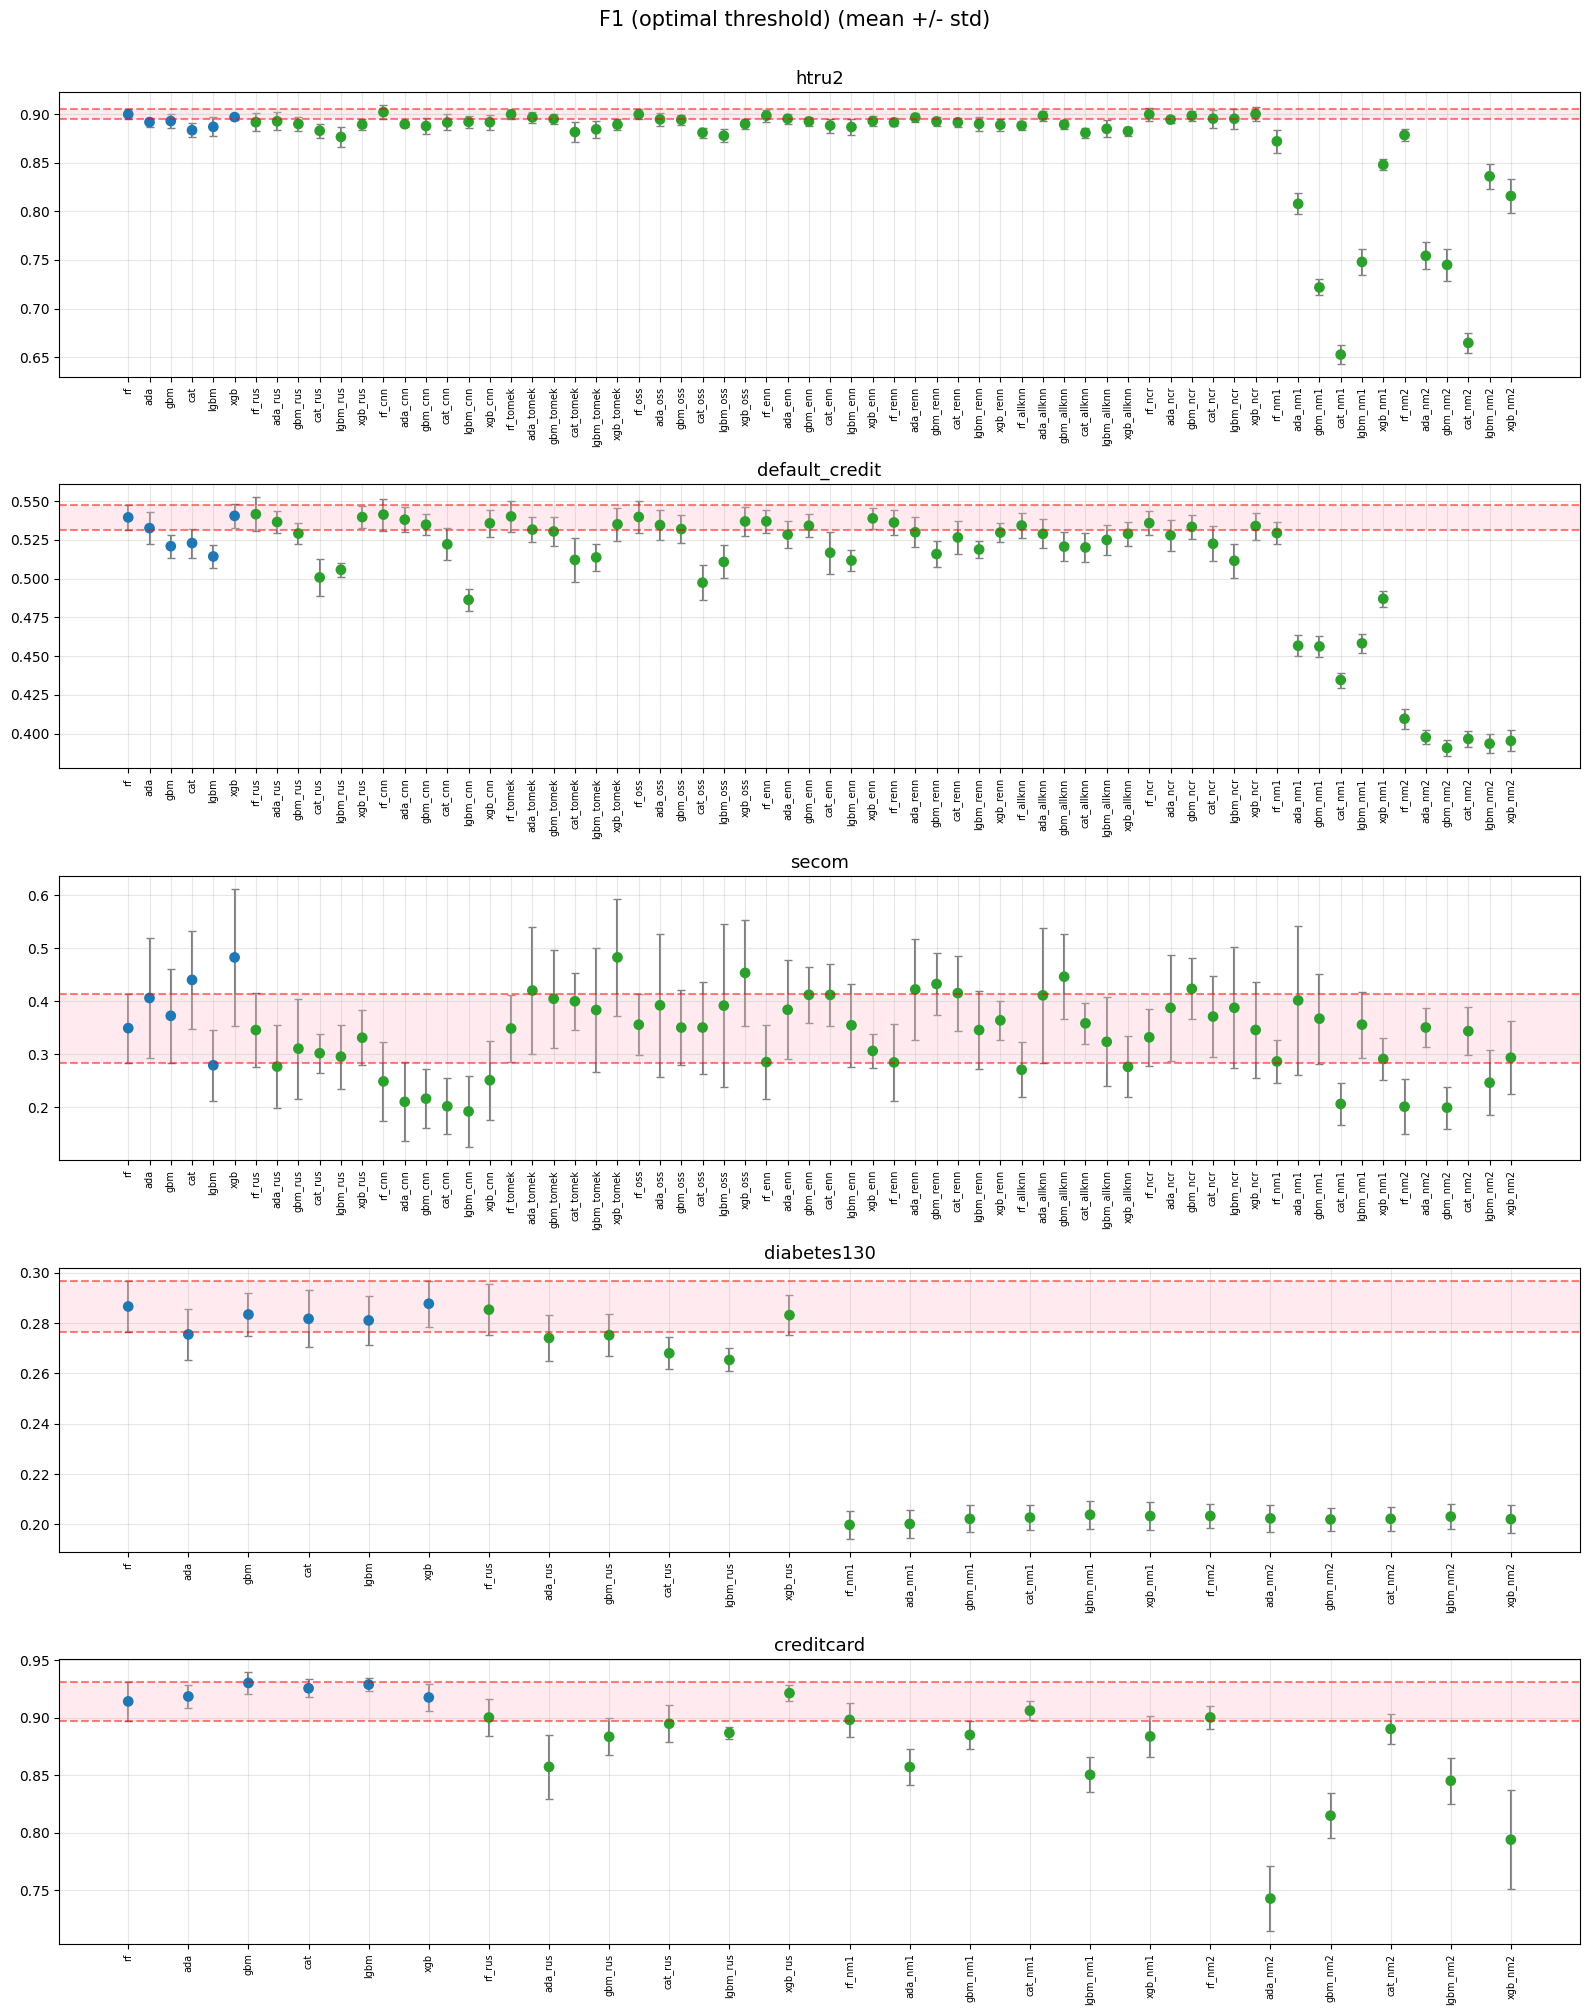

In [10]:
plot_metric('f1_score', 'f1_std', 'F1 (optimal threshold) (mean +/- std)', '../figures/undersampling-new_f1.png')

## Combined table

In [11]:
dfs = [create_df(scores_dict, d, list(scores_dict[d].keys())) for d in datasets]
result = pd.concat(dfs, keys=datasets, names=['dataset', 'model'])
result.to_csv('../results/undersampling-new_models_performance.csv')
result[['roc', 'ap', 'f1_score', 'mcc', 'ba', 'gmean']].round(3)

roc     ap  f1_score    mcc     ba  gmean
dataset    model                                                
htru2      rf        0.976  0.926     0.900  0.892  0.952  0.951
           ada       0.976  0.914     0.892  0.883  0.948  0.947
           gbm       0.979  0.927     0.893  0.884  0.949  0.949
           cat       0.974  0.917     0.884  0.875  0.943  0.942
           lgbm      0.973  0.918     0.887  0.878  0.944  0.944
...                    ...    ...       ...    ...    ...    ...
creditcard ada_nm2   0.952  0.766     0.743  0.738  0.923  0.921
           gbm_nm2   0.948  0.833     0.815  0.811  0.935  0.934
           cat_nm2   0.956  0.864     0.890  0.891  0.935  0.934
           lgbm_nm2  0.951  0.857     0.845  0.843  0.935  0.934
           xgb_nm2   0.954  0.822     0.794  0.803  0.936  0.936

[246 rows x 6 columns]

## Does any undersampler beat the plain ensemble?

For each dataset and metric, compare the **best undersampled ensemble** against
the **best plain ensemble**. Positive delta means undersampling helped.

In [12]:
metric_cols = {'roc': 'roc', 'ap': 'ap', 'f1': 'f1_score', 'mcc': 'mcc',
               'ba': 'ba', 'gmean': 'gmean'}
rows = []
for ds in datasets:
    keys = list(scores_dict[ds].keys())
    under = [k for k in keys if k not in plain_models]
    df = create_df(scores_dict, ds, keys)
    for short, col in metric_cols.items():
        best_plain = df.loc[plain_models, col].max()
        best_under = df.loc[under, col].max()
        rows.append({'dataset': ds, 'metric': short,
                     'best_plain': round(float(best_plain), 3),
                     'best_undersampled': round(float(best_under), 3),
                     'best_under_model': df.loc[under, col].idxmax(),
                     'delta': round(float(best_under - best_plain), 3)})
summary = pd.DataFrame(rows)
summary

,dataset,metric,best_plain,best_undersampled,best_under_model,delta
0,htru2,roc,0.979,0.979,xgb_oss,-0.000
1,htru2,ap,0.927,0.930,gbm_tomek,0.003
2,htru2,f1,0.900,0.902,rf_cnn,0.002
3,htru2,mcc,0.892,0.894,rf_cnn,0.002
4,htru2,ba,0.952,0.954,rf_ncr,0.002
5,htru2,gmean,0.951,0.954,gbm_ncr,0.002
6,default_credit,roc,0.784,0.784,rf_enn,-0.000
7,default_credit,ap,0.546,0.544,rf_oss,-0.002
8,default_credit,f1,0.540,0.542,rf_rus,0.001
9,default_credit,mcc,0.426,0.424,xgb_oss,-0.002


In [13]:
wins = (summary['delta'] > 0).sum()
print(f'Undersampling beats best plain ensemble in {wins}/{len(summary)} (dataset, metric) cells')
print(f'Mean delta (best undersampled - best plain): {summary.delta.mean():+.3f}')
summary.pivot(index='dataset', columns='metric', values='delta')[['roc','ap','f1','mcc','ba','gmean']]

Undersampling beats best plain ensemble in 14/30 (dataset, metric) cells
Mean delta (best undersampled - best plain): +0.001


metric,roc,ap,f1,mcc,ba,gmean
dataset,,,,,,
creditcard,0.001,-0.018,-0.009,-0.009,0.004,0.004
default_credit,-0.000,-0.002,0.001,-0.002,-0.001,-0.003
diabetes130,-0.004,-0.016,-0.002,-0.006,-0.004,-0.003
htru2,-0.000,0.003,0.002,0.002,0.002,0.002
secom,0.015,0.019,0.000,0.020,0.018,0.023


## Conclusion

Two questions, two answers.

**1. Do the cleaning methods remove more on less-separable data? Yes, clearly.**
The edited-NN methods strip far more of the majority on the harder datasets:
ENN removes 3.7% on htru2 (ROC-AUC ~0.98) but 30.5% on default_credit (~0.78);
RENN 4.6% -> 44.2%; AllKNN 6.6% -> 53.3%; NCR 3.9% -> 27.1%. When the classes
overlap there are many more borderline majority points for these methods to
drop, exactly as expected.

**2. Does removing them improve performance? Mostly no, with one suggestive
exception.** Across the five datasets and six metrics the best undersampled
ensemble beats the best plain ensemble in 14/30 cells but by a mean of only
+0.001 -- a wash. On htru2, default_credit, diabetes130 and creditcard it is
tied or slightly worse at the optimal threshold.

The exception is **secom** -- the hardest, lowest-separability, highest-
dimensional dataset -- where the cleaning methods nudge every metric up (MCC
+0.02, average precision +0.02, balanced accuracy +0.02 vs the best plain
ensemble). This is the one place the 'drop the hard-to-classify examples' idea
seems to pay off, and it's specifically the *cleaning* methods doing it: plain
RandomUnderSampler actually hurts secom (it discards signal at random) while the
targeted edited-NN methods do not. secom's test set is small (~26 positive
cases), so the error bars are wide and this is suggestive rather than
conclusive.

So the overall picture holds with notebooks 05-06: at the optimal threshold,
resampling does not reliably beat a well-tuned standard ensemble. The nuance
worth keeping is that on heavily-overlapping, high-dimensional data the cleaning
methods are the one form of resampling that at least doesn't hurt and may
modestly help -- consistent with their design rationale, and worth a closer look
on more datasets of that kind.

**Scope.** Full 10-method suite on htru2, default_credit and secom;
RandomUnderSampler and NearMiss on diabetes130 and creditcard (the
neighbour-based methods are days-scale on those).
